# Compulsory Assignment 1: Dense neural networks - Implementing an ANN with Keras

Please fill out the the group name, number, members and optionally the group name below. 

**Group number**: 19\
**Group member 1**: Matthieu Jouyit\
**Group member 2**: Paul-Adrien Lu-Yen-Tung\
**Group member 3**: Emre Can Emer\
**Group name (optional)**: 

# Assignment submission

To complete this assignment, answer the all the questions in this notebook and write the code required to implement different models. **Submit the assignment by handing in this notebook as both an .ipynb file and a .pdf file**.

Here are some do’s and don’ts for the submission:

- Read questions thoroughly before answering.
- Make sure to answer all questions.
- Ensure all code cells are run.
- Label all axes in plots.
- Ensure all figures are visible in the PDF.

# Introduction 

In this assignment we will continue with the task of classifying handwritten digits from the MNIST dataset, used in the voluntary assignment where we designed a neural network from scratch. But, today you will implement the network using the Keras API of the TensorFlow library. TensorFlow and PyTorch are both free open-source software libraries intended to simplify multiplication of tensors, but are mostly used for the design and implementation of deep neural networks. Both libraries simplify the implementation of neural networks, and allow for faster training of networks by utlizing hardware acceleration with Graphical Processing Units (GPUs) or Tensor Processing Units (TPUs)

TensorFlow was developed by Google Brain for internal use in Google and was initially released under Apache 2.0 License in 2015 [1](https://en.wikipedia.org/wiki/TensorFlow). Keras was initially released as separate software library, developed by François Chollet, to simplify the Python interface for design of artificial neural networks. Up until version 2.3 Keras supported multiple backend libraries including TensorFlow, Microsoft Cognitive Toolkit, Theano, and PlaidML [2](https://en.wikipedia.org/wiki/Keras). When TensorFlow 2.0 was released in 2019, keras was included as a TensorFlow specific API that is accessible by:

```python
import tensorflow.keras as ks
```
PyTorch was originally developed by Meta AI (formerly known as Facebook) in 2016, but is now under umbrella of the Linux foundation, and is open-source under the BSD license [3](https://en.wikipedia.org/wiki/PyTorch). While TensorFlow was the most popular framework for a long time, PyTorch has been gaining more and more users in the last five years and is now more used in industry and is becoming more popular in research as well. 

The lectures of DAT300 will be taught using the Keras API in TensorFlow, and we recommend you to stick with Keras and TensorFlow for this course as it is easier for beginners to get started with. 

## Assignment structure

1. Part 1: Import, preprocess, and visualize the data.
2. Part 2: Use the Keras API to implement a Dense Neural Network (NN) that resembles the model given in the voluntary assignment.
3. Part 3: Design your own Dense Neural Network (NN) architecture for classifying MNIST in Keras.
4. Part 4: Train a Machine Learning classifier that you learned about in DAT200.
5. Part 5: Compare and discuss the results.

## Note on the voluntary assignment

Some of the questions in this task will ask you to compare the results from training this network to the results you had in the voluntary assignment with regard to training algorithm used and the time it took to train the network implemented with Numpy and with TensorFlow/PyTorch. If you did not do the voluntary assignment yourself, have a look at the solutions that should be posted and run through the solutions-notebook to get the results you need for a comparison.


## Library imports

In [1]:
import time
from tqdm import tqdm # Cool progress bar

import numpy as np
import pandas as pd
import tensorflow.keras as ks
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

import matplotlib.pyplot as plt
import seaborn as sns

from utilities import *

SEED = 458
RNG = np.random.default_rng(SEED) # Random number generator

# Task 1: Importing, preprocess and visualizing the data
To import the data of the MNIST dataset for this assignment
* Copy the data/ folder from the folder where you kept the last assignment, and run the load_data() function from the `utilities.py` file.
* Just download the data again by re-running the load_data() function from the `utilities.py` file.

In this assignment you yourselves will be responsible for the data-preprocessing. Use the cells below for preprocessing and visualization, and optionally some exploration of the dataset if you feel inclined. 

## Importing data

In [2]:
# Code provided by teacher.
datasets = load_mnist(verbose=1)
X_train, y_train = datasets['X_train'], datasets['y_train']
X_val,   y_val   = datasets['X_val'],   datasets['y_val']
X_test,  y_test  = datasets['X_test'],  datasets['y_test']

X_train = np.concatenate([X_train, X_val], axis=0)
y_train = np.concatenate([y_train, y_val], axis=0).astype('int32')

del datasets, X_val, y_val # Good to reduce uneccesary RAM usage

X_train shape (50000, 28, 28)
y_train shape (50000,)
X_val shape (10000, 28, 28)
y_val shape (10000,)
X_test shape (10000, 28, 28)
y_test shape (10000,)
small_X_train shape (3000, 28, 28)
small_y_train shape (3000,)
small_X_val shape (500, 28, 28)
small_y_val shape (10000,)


## Task 1.1 Preprocessing
Preprocess the data in whatever way you find sensible. Remember to comment on what you do.

In [3]:
# Data comes in pixel values (RGB values are from 0 to 255).
# For machine learning purposes, we want the values between 0 and 1.
# Doing this here is useful since the older model we use below requires this anyway.

X_train = X_train/255
X_test = X_test /255

## Task 1.2 Visualization
Visualize the data in whatever manner you find helpful/sensible and briefly comment on the plots.

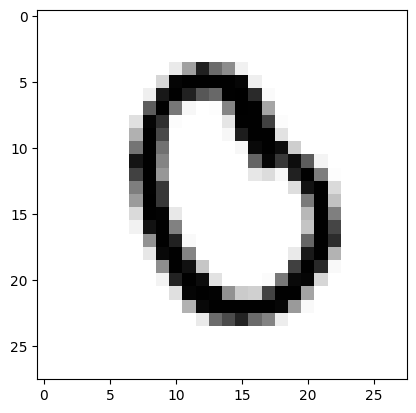

In [4]:
# Data contains pixel data, plottings an entire row of pixel data gives us an image.
plt.imshow(X_train[1], cmap='Greys')

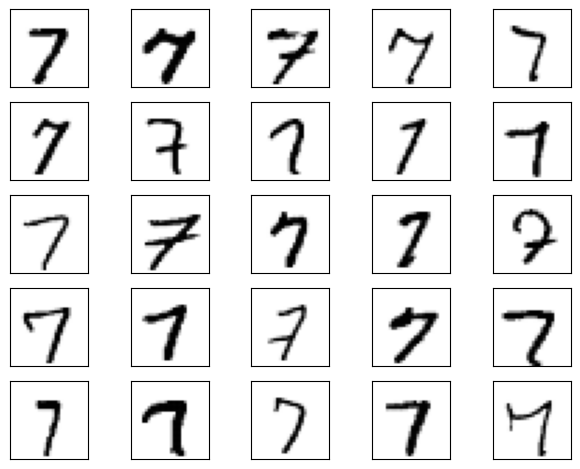

In [5]:
# I took the code below from teacher's lesson notes. It is a good visualization.
fig, ax = plt.subplots(nrows=5, ncols=5, sharex=True, sharey=True,)
ax = ax.flatten()
for i in range(25):
    img = X_train[y_train == 7][i].reshape(28, 28)
    ax[i].imshow(img, cmap='Greys')

ax[0].set_xticks([]); ax[0].set_yticks([])
plt.tight_layout()
plt.show()

# Task 2: TensorFlow vs. Numpy
In this task you will redesign the network you implemented in Numpy (from the voluntary assignment) using TensorFlow, and then compare the two implementations.
## Task 2.1: Implement the F1-score
In the cell below, implement or import a function for the F1-score metric.

In [ ]:
from sklearn.metrics import f1_score

# Do I have to use an external imported f1 function like above or are we allowed to use the built in one?
# I used the F1-score method that already exists in the keras.metrics method.
# Using this for the DAT200 SVC model below.

## Task 2.2: Implement the network from the voluntary assignment
Implement a network with the following architecture:
* Input layer: (28, 28)
* Hidden layer: 30 units, sigmoid activation
* Output layer: 10 units, sigmoid activation

Compile the model using:
* The `'MSE'` loss function
* The `SGD` optimizer with `learning_rate=0.25`
* both `'accuracy'` and the implementation of the **F1-score** from Task 2.1 as metrics

Train the model using:
* batch size of 10 images
* 5 epochs
* A validation split of 1/6

Implement the model in the code cell(s) below.

In [7]:
# Setting up the model according to parameters above.
model = keras.Sequential([
    layers.Flatten(input_shape=(28,28)),
    layers.Dense(30, activation="sigmoid"),
    layers.Dense(10, activation="sigmoid")
])

model.summary()

# Using the built-in F1_score metrics.
model.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.25),
    loss='MSE',
    metrics=['accuracy',
             tf.keras.metrics.F1Score(average='macro', name='f1_score')]
)

c:\Users\emryc\anaconda3\envs\dat300-env\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 30)             │        23,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           310 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,860 (93.20 KB)

 Trainable params: 23,860 (93.20 KB)

 Non-trainable params: 0 (0.00 B)

## Task 2.3: Train the network and plot the training history
Train the model and plot the training history in the code cell(s) below. Use the same method for plotting the training process as in the voluntary assignment. Feel free to use the function `plot_training_history()` from `utilities.py`

Epoch 1/5
5004/5004 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.6509 - f1_score: 0.6158 - loss: 0.0611 - val_accuracy: 0.8258 - val_f1_score: 0.8149 - val_loss: 0.0379
Epoch 2/5
5004/5004 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.8630 - f1_score: 0.8589 - loss: 0.0300 - val_accuracy: 0.8740 - val_f1_score: 0.8708 - val_loss: 0.0257
Epoch 3/5
5004/5004 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.8877 - f1_score: 0.8853 - loss: 0.0226 - val_accuracy: 0.8908 - val_f1_score: 0.8890 - val_loss: 0.0213
Epoch 4/5
5004/5004 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.8976 - f1_score: 0.8956 - loss: 0.0195 - val_accuracy: 0.8975 - val_f1_score: 0.8958 - val_loss: 0.0192
Epoch 5/5
5004/5004 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9045 - f1_score: 0.9028 - loss: 0.0177 - val_accuracy: 0.9027 - val_f1_score: 0.9014 - val_loss: 0.0177


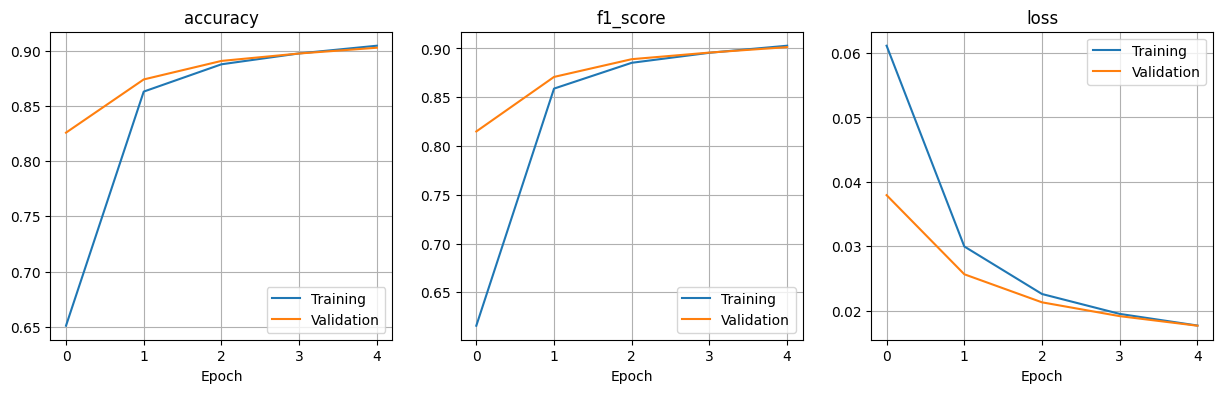

In [8]:
# Using one hot decoder to turn labels into matrices. Otherwise we get dimension errors.
y_onehot_train = tf.one_hot(y_train, 10)

training = model.fit(X_train, y_onehot_train, epochs=5, batch_size=10, validation_split=0.166)
plot_training_history(training)

In [10]:
# model.evaluate(X_test, y_test)

## Task 2.4: Compare the results from the TensorFlow implementation with the Numpy implementation
**Question 2.4.1**: How long did it take to train the TensorFlow implementation of the network on the *entire* dataset for five epochs compared to the time it took to train the Numpy implementation?

**Question 2.4.2**: What is the biggest (defining) difference in how the TensorFlow implementation **was trained** compared to the Numpy implementation?

**Question 2.4.3**: Were there any significant differences in the ease of implementation and the amount of code needed for the TensorFlow and Numpy implementations?

**Answer 2.4.1**:   (If I'm understanding the question correctly.) Numpy implementation in the voluntary assignment is 10 times faster than the TensorFlow model. 

**Answer 2.4.2**: We trained the numpy implementation manually entirely. Tensorflow has a large arthitechture and uses optimizers to basically "model" the data  automatically. For example, in numpy we coded batches, epochs etc. everything outselves.

**Answer 2.4.3**:Tensorflow is a ready-to-use library. In the numpy implementation we wrote the functions and their inner workings ourselves. In this case, the amount of code needed for numpy is much larger than the tensorflow implementation.

# Task 3: Design your own ANN architecture
As you probably noticed in the last task, the performance of the simple network with a single hidden layer and 30 hidden units does not perform particularly well. In this task you are free to design the network architecture for the MNIST handwritten digit recognition challenge with a couple of stipulations:
* use **only Dense or fully connected layers**,
* use both **accuracy and the F1-score** as performance metrics. 

Otherwise, you are free to use whatever loss-function, optimizer and activation functions you want and train it for as many epochs you want.

## Task 3.1: Implement your own network architecture
Design your network below:

(Feel free to add as many code and markdown cells as you want)

In [ ]:
# Own network architecture.
my_model = keras.Sequential([
    layers.Flatten(input_shape=(28,28)),
    layers.Dense(30, activation="relu"),   # decided to use RELU since it is supposed to be better optimized for image processing.
    layers.Dense(10, activation="softmax")
])

my_model.summary()

# Adam is also SGD (https://keras.io/api/optimizers/adam/) however, it is supposed use an adaptive learning rate instead of a 
# globally set one like we used above. 
my_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',    # Docs suggest it is good for multi-class datasets. Link in question answers.
    metrics=['accuracy',
             tf.keras.metrics.F1Score(average='macro', name='f1_score')]
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 30)             │        23,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           310 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,860 (93.20 KB)

 Trainable params: 23,860 (93.20 KB)

 Non-trainable params: 0 (0.00 B)

## Task 3.2: Train your network and visualize the training history
Train the model and plot the training history in the code cell(s) below. Use the same method for plotting the training process as in the voluntary assignment. Feel free to use the function `plot_training_history()` from `utilities.py`

Epoch 1/10
4800/4800 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.9002 - f1_score: 0.8989 - loss: 0.3458 - val_accuracy: 0.9342 - val_f1_score: 0.9339 - val_loss: 0.2221
Epoch 2/10
4800/4800 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9452 - f1_score: 0.9446 - loss: 0.1879 - val_accuracy: 0.9491 - val_f1_score: 0.9488 - val_loss: 0.1742
Epoch 3/10
4800/4800 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9575 - f1_score: 0.9570 - loss: 0.1452 - val_accuracy: 0.9551 - val_f1_score: 0.9549 - val_loss: 0.1536
Epoch 4/10
4800/4800 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9628 - f1_score: 0.9624 - loss: 0.1217 - val_accuracy: 0.9590 - val_f1_score: 0.9588 - val_loss: 0.1423
Epoch 5/10
4800/4800 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.9684 - f1_score: 0.9681 - loss: 0.1047 - val_accuracy: 0.9600 - val_f1_score: 0.9597 - val_loss: 0.1377
Epoch 6/10
4800/4800 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.9716 - f1_score: 0.9714 - loss: 0.0925 - val_accuracy: 0.9626 - va

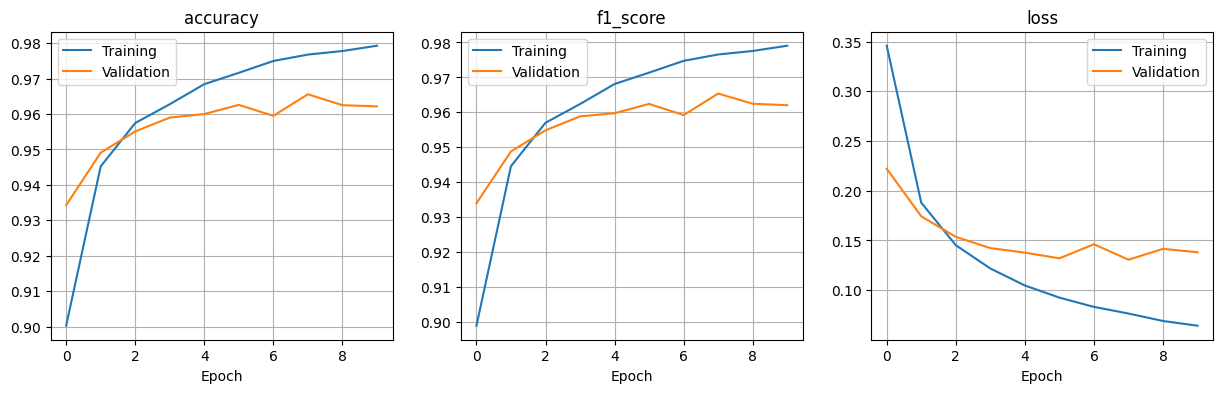

In [12]:
training_2 = my_model.fit(X_train, y_onehot_train, epochs=10, batch_size=10, validation_split=0.2)
plot_training_history(training_2)

## Task 3.3: Discuss the results
**Question 3.3.1**: Compare the performance of your new model with the model from Task 2. Did the new model achieve higher accuracy and F1-score? What could be the reasons for that?

**Question 3.3.2**: Did overfitting occur? If so, after how many epochs? Does overfitting typically increase or decrease with the increasing model complexity?

**Question 3.3.3**: How do accuracy and F1-Score values compare (are they similar or very different from each other)? What does it tell you about the MNIST dataset and which one of these metrics is more reliable in this case?

**Question 3.3.4**: Explain **very briefly** how each of the following model hyperparameters can impact the model's performance:
- Number of layers
- Number of neurons in a layer
- Activation functions
- Learning rate.
- Regularization techniques (such as L2 regularization).

**Answer 3.3.1**: New model achieved higher accuracies and F1-scores. Possible reasons for this occuring:
    - We used RELU for one of the custom models, which is supposed to have better performance in image processing.
    - In the docs, Categorical cross entropy is used for a good performance option for multi-class classification.
        https://www.tensorflow.org/api_docs/python/tf/keras/losses/CategoricalCrossentropy
    - Models with denser layers shown to have better performance.

**Answer 3.3.2**: Yes. It can be seen clearly in the first model. After epoch 2 (best case epoch 4), validation accuracy stagnates while training data keeps rising. This is a strong indication that training data has started to memorize patterns and started to pick up noise. 

**Answer 3.3.3**:Accuracy and F1-score values are not exactly the same but very similar.I remember from DAT200 that F1-score is a good metric for imbalanced datasets. For example, in the iris database we have different amount of data for different types of flowers. F1 would be better here. However, since MNIST database is balanced (same amount of data for each number), we see very similar accuracy and F1-score metrics.

**Answer 3.3.4**:
- **Number of layers** It directly increases or decreases a models complexity. Less can mean underfitting, more can overfit.
- **Number of neurons in a layer** Mostly the same attributes as layers above. Many neurons can increase training time a lot.
- **Activation functions** It directly influences the models performance on different types of datasets. Linear vs non-linear data for example.
- **Learning rate** I remember teacher showing how learning rate works in class. If we take a simple curve and try to get to the minimum, and if the learning rate is too high, we might overshoot and end up on the other side of the curve.
- **Regularization techniques (L2 etc.)** Defines how to treat training error. For example, by taking the squared value of the weights, it makes sure higher magnitude errors does not dominate.

# Task 4: Design and train a _classical_ machine learning classifier
Pick your **favourite** machine learning classifer that you learned about in DAT200 and train it for the MNIST handwritten digits recognition problem. (Hint: use the scikit-learn library). Remember to use **accuracy and the F1-score** as performance metrics.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.svm import SVC
# from sklearn.decomposition import PCA

# I took the code below from my work on 4th compulsory assignment in DAT200. It's the SVC model we trained back then just
# readjusted to train on MNIST database. I picked this because SVC with rbf kernel is supposed to give good performance
# on a complex database like MNIST.

# Flattening the dataset (X_train etc.) we get from teacher's function.
# It's like the flatten layer in tensorflow but manual. I had to look this up.
# I also take a subsample for demonstration purposes because otherwise its takes over 10 MINUTES to train.
X_train_svc = X_train[:10000].reshape(10000, -1).astype('float32')
y_train_svc = y_train[:10000]

X_test_svc = X_test.reshape(X_test.shape[0], -1).astype('float32')

# Standard train test split.
X_train_svc_2, X_test_svc_2, y_train_svc_2, y_test_svc_2 = train_test_split(
    X_train_svc, y_train_svc, test_size=0.2,
    stratify=y_train_svc, random_state=42)

# I removed the PCA since it reduced model performance by half.
pipeline = Pipeline([
    ('scaler', StandardScaler()),                   # Step 1: Data scaling
    # ('pca', PCA(n_components=3)),                 # Step 2: PCA with three components
    ('svc', SVC(kernel='rbf', C = 3.0))             # Step 3: Support Vector Classifier
])

# Fitting the pipeline on training data.
pipeline.fit(X_train_svc_2, y_train_svc_2)

# Making predictions.
predictions = pipeline.predict(X_test_svc_2)

# Evaluating the model.
train_accuracy = pipeline.score(X_train_svc_2, y_train_svc_2)
test_accuracy  = pipeline.score(X_test_svc_2, y_test_svc_2)
f1_accuracy = f1_score(y_test_svc_2, predictions, average='macro')

pipeline

,steps,"[('scaler', ...), ('svc', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,3.0
,kernel,'rbf'
,degree,3
,gamma,'scale'


In [ ]:
print(f'SVC - TRAIN accuracy     = {train_accuracy:.3f}')
print(f'SVC - TEST accuracy      = {test_accuracy:.3f}')
print(f'SVC - TEST accuracy (F1) = {f1_accuracy:.3f}')

# SVC performance exceeded expectations honestly.

SVC - TRAIN accuracy     = 0.996
SVC - TEST accuracy      = 0.938
SVC - TEST accuracy (F1) = 0.938


# Task 5: Compare and discuss
Evaluate the four models you have implemented in task 2, 3 and 4 on the test dataset and compare them based on
* Accuracies and F1-scores they attain
* Time it takes to train them

Did you experience any trouble when training models in tasks 2-4?

**Task 5 discussion Here:**


Numpy model is by far the fastest and worst performing model. With training time of 5.4 seconds and loss of 0.2427. Training time makes sense since numpy is a very efficient library and we wrote only the code we needed. Other libraries such as tensorflow have a very large architecture behind them. This is a plus when training very large and/or complex models but for MNIST it can be quite overkill.

Classical (SVC) model comes in last in training time however it is one of the best in accuracy. With training time of over 10 minutes (code might show 35 seconds but it uses subsamples from the dataset for demonstration purposes) and accuracy of 0.938 (also in F1). The high accuracy was a surprise. Although MNIST is a very balanced dataset. Experienced a bit of a trouble in training this model since we had to further adjust the data a bit. Keras' flatten layer automatically does the job for us for a classical model like SVC we had to flatten the data outselves.

Our custom network comes in second to last in training time but is one of the best in accuracy. With training time if 45 seconds and accuracy of 0.9791 (0.9793 F1). This results was expected. We handpicked the optimizers and activation functions that would work very well with MNIST (relu and softmax). We tried to avoid increasing the layers and numbers of neurons to avoid complexity problems like vanishing gradients and overfitting. 

However, even with same number of layers and neurons, this model showed signs of overfitting after 4th epoch. This can be seen clearly in the visualization of the training and the validation data. Training accuracy steadily climbs while validation data stagnates. This is in indicator of model starting to pick up on noisy data and/or memorize it.

Network with pre-determined hyperparameters comes in as second fastest and with moderate accuracy results. With accuracy of 0.9045 (0.9028 F1). This model was used as baseline comparison for other models.
